In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [21]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=',')
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,512,200,0.000100,1,1.000,1.0,0.1,1,400,0.515979,0.000307,902.727500,1.136105,1.853617e+05,2.274492e+02
1,bond,2,1024,200,0.000100,1,1.000,1.0,0.1,1,300,0.503357,0.000215,2479.286667,10.155359,5.008074e+05,2.028820e+03
2,bond,2,2000,200,0.000100,1,1.000,1.0,0.1,1,1,0.500356,0.004359,5915.000000,0.000000,1.186322e+06,0.000000e+00
3,bond,2,2048,200,0.000100,1,1.000,1.0,0.1,1,200,0.501575,0.000165,6809.170000,74.156827,1.351225e+06,1.596092e+04
4,bond,2,2048,400,0.000010,2,0.125,1.0,0.1,1,100,0.515225,0.000384,3799.390000,4.583477,1.135726e+06,3.008000e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16037,bond,3,1024,3000,0.000001,8,0.125,1.0,0.1,4,10,0.250344,0.000134,6931.000000,57.165646,1.709806e+07,1.285516e+06
16038,bond,3,1024,3000,0.000001,8,0.125,1.0,0.1,5,10,0.250352,0.000124,6830.500000,44.251365,1.589769e+07,1.168986e+06
16039,bond,3,1024,3000,0.000001,8,0.125,1.0,0.1,6,10,0.249986,0.000111,6862.700000,70.860277,1.644904e+07,9.010302e+05
16040,bond,3,1024,3000,0.000001,8,0.125,1.0,0.1,7,10,0.250597,0.000163,6942.800000,31.849926,1.757772e+07,1.257520e+06


## $n_c = 1$

[WARN] Nenhum dado encontrado para k = 6e-06
minimum value for k=1e-05, $\langle p \rangle$ = 0.2504919635524545 for f = 0.02
minimum value for k=5e-05, $\langle p \rangle$ = 0.2496054922322297 for f = 0.01
    type_perc  dim    L    Nt        k  nc  rho   p0   P0  order  N_samples  \
169      bond    3  128   327  0.00001   1  1.0  1.0  0.1      1         83   
170      bond    3  128   491  0.00001   1  1.0  1.0  0.1      1        285   
171      bond    3  128   655  0.00001   1  1.0  1.0  0.1      1        300   
173      bond    3  128   819  0.00001   1  1.0  1.0  0.1      1        311   
174      bond    3  128   983  0.00001   1  1.0  1.0  0.1      1        300   
175      bond    3  128  1146  0.00001   1  1.0  1.0  0.1      1        300   
176      bond    3  128  1310  0.00001   1  1.0  1.0  0.1      1        300   
178      bond    3  128  1474  0.00001   1  1.0  1.0  0.1      1        300   
179      bond    3  128  1638  0.00001   1  1.0  1.0  0.1      1        300   
180

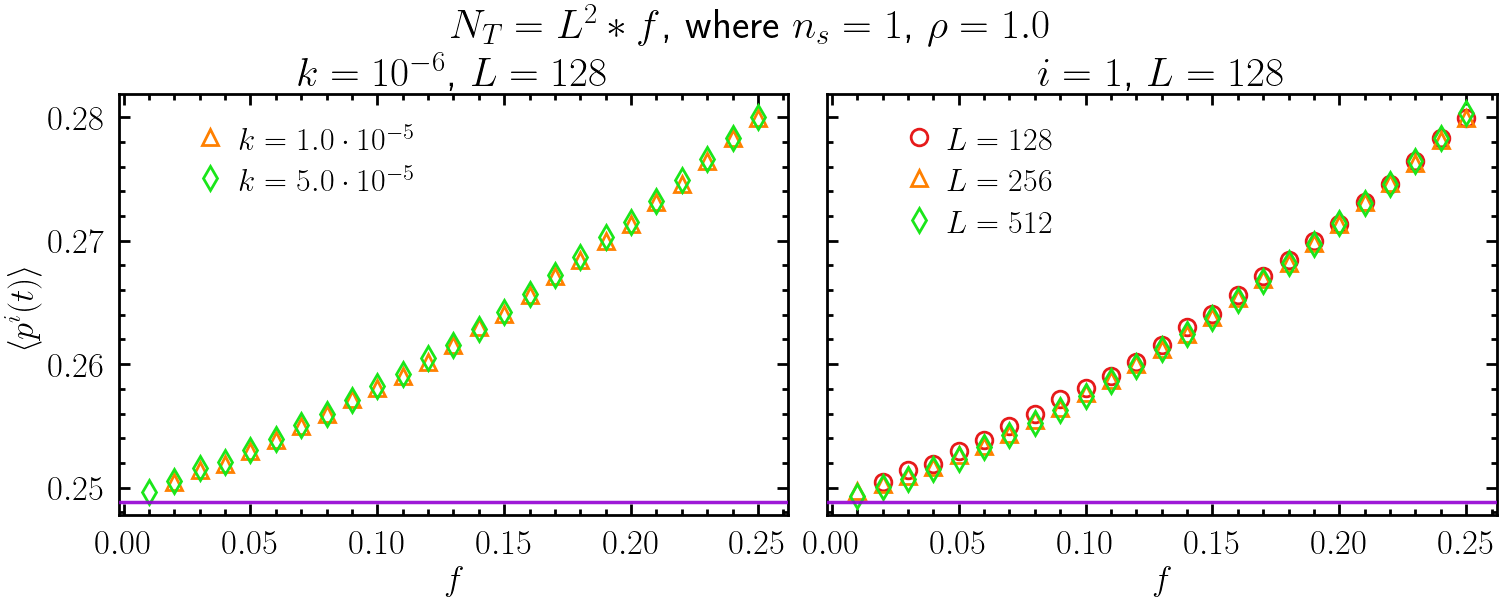

In [63]:
L_lst = [128, 256, 512]
dim = 3
nc = 1
rho = 1/nc
k_lst = [6.e-06, 1.e-05, 5.e-05]
ord = 1

colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30


for idx, k in enumerate(k_lst):
    L = L_lst[0]
    A = L**2
    df_sub = df[
        (df['L'] == L) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['dim'] == dim) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()


    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[0].plot(
        f_list, pk_list,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

for idx, l in enumerate(L_lst):
    ord = 1
    k = 1.0e-05
    mantissa_L, exp_L = f"{k:.1e}".split("e")
    df_sub = df[(df['L']==l) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    print(df_sub)
    A = l**2
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    axes[1].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$L = {l}$')


for ax in axes:
    leg = ax.legend(
        loc="upper left",
        fontsize=fs_legend,
        bbox_to_anchor=(0.08, 0.98),  # move para direita e levemente para baixo
        frameon=False,
        handletextpad=0.4,   # aproxima símbolo do texto
        labelspacing=0.35,   # reduz espaço vertical
        handlelength=1.0,    # encurta área do símbolo
        handleheight=0.9,
        borderpad=0.2,
        markerscale=1.0
    )
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$, $L = {L}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$, $L = {L}$", fontsize=fs_text)
#axes[2].set_title(f"$i = 1$, $k = {mantissa_L} \\cdot 10^{{{-6}}}$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()

minimum value i=1, $\rho$ = 0.253244733437612 for f = 0.02
minimum value i=2, $\rho$ = 0.2531267516623136 for f = 0.01
minimum value for k=0.0001, $\langle p \rangle$ = 0.2532642019450709 for f = 0.02
minimum value for k=5e-05, $\langle p \rangle$ = 0.253244733437612 for f = 0.02
minimum value for k=1e-05, $\langle p \rangle$ = 0.25339076020945 for f = 0.02
minimum value for k=5e-05, $\langle p \rangle$ = 0.253244733437612 for f = 0.02
minimum value for k=6e-06, $\langle p \rangle$ = 0.2546111552399124 for f = 0.03


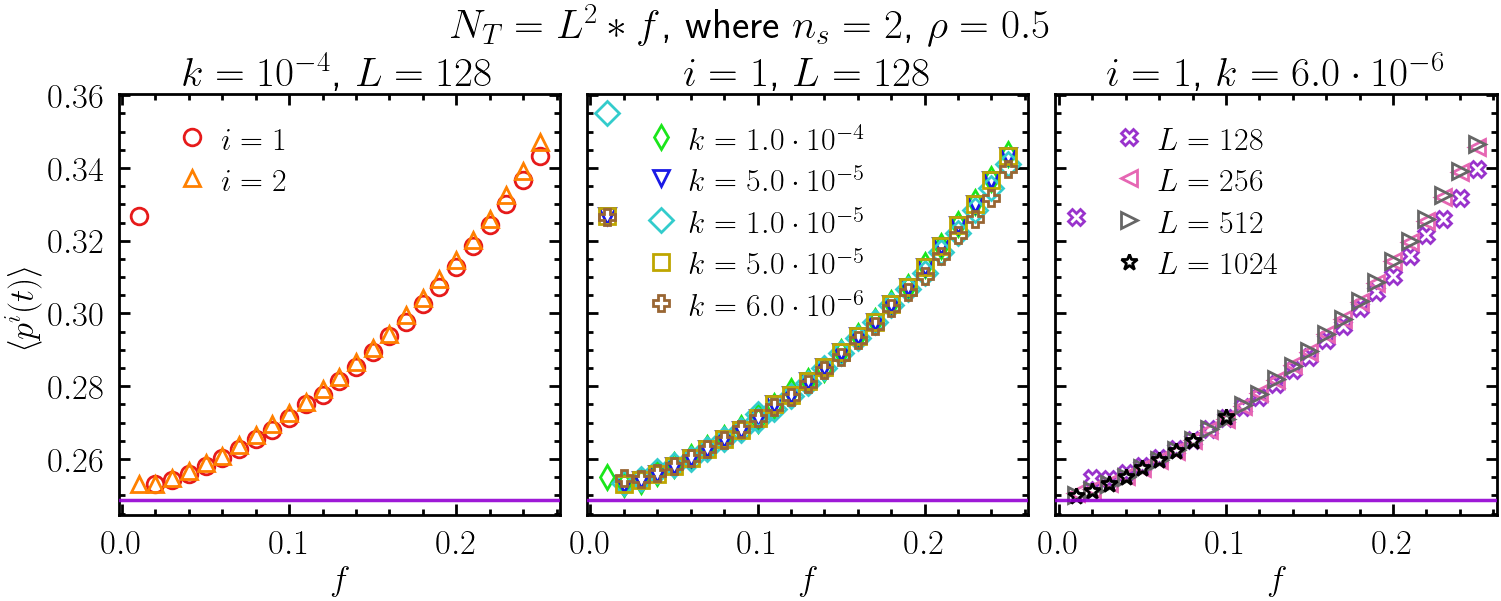

In [8]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 128
nc = 2
dim = 3
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),   # red
    (1.0, 0.5, 0.0),   # orange
    (0.1, 0.9, 0.1),   # green
    (0.1, 0.1, 0.9),   # blue
    (0.2, 0.8, 0.8),   # teal
    (0.75,0.65, 0.00),   # yellow
    (0.6, 0.4, 0.2),   # brown
    (0.6, 0.2, 0.8),   # purple
    (0.9, 0.4, 0.7),   # pink
    (0.4, 0.4, 0.4),   # gray
    (0.0, 0.0, 0.0),   # black
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 3, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", "D", "s", "P", "X", "<", ">", "*"]
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k_lst[1])]
    
    f_list = [round(i/A,4) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == L) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['dim'] == dim) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()

    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    # print(f"\nk = {k:.1e}")
    # print("Nt existentes :", nt_existentes)
    # print("Nt faltando   :", nt_faltando)
    # print("f faltando    :", f_faltando)

    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[len(orders)+idx],
        color=colors[len(orders)+idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

L_lst = [128, 256, 512, 1024]

for idx, l in enumerate(L_lst):
    ord = 1
    k = 6.0e-6
    mantissa_L, exp_L = f"{k:.1e}".split("e")
    df_sub = df[(df['L']==l) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    A = l**2
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    axes[2].plot(f_list, pk_list, marker=markers[len(orders) + len(k_lst) + idx], color=colors[len(orders) + len(k_lst) + idx], 
                 ls="None", mew=mew, ms=ms, label=f'$L = {l}$')


for ax in axes:
    leg = ax.legend(
        loc="upper left",
        fontsize=fs_legend,
        bbox_to_anchor=(0.08, 0.98),  # move para direita e levemente para baixo
        frameon=False,
        handletextpad=0.4,   # aproxima símbolo do texto
        labelspacing=0.35,   # reduz espaço vertical
        handlelength=1.0,    # encurta área do símbolo
        handleheight=0.9,
        borderpad=0.2,
        markerscale=1.0
    )
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$, $L = {L}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$, $L = {L}$", fontsize=fs_text)
axes[2].set_title(f"$i = 1$, $k = {mantissa_L} \\cdot 10^{{{-6}}}$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()

128 7943    0.413140
7947    0.257871
7951    0.260581
7955    0.265619
7963    0.270372
7967    0.275689
7971    0.282183
7975    0.287308
7983    0.294013
7991    0.300561
7995    0.305805
7999    0.312967
8007    0.322441
8011    0.331497
8015    0.344241
8019    0.389820
8027    0.487408
8031    0.623843
8039    0.741911
8043    0.853071
8051    0.912301
8055    0.953761
8059    0.964371
8063    0.968739
8071    0.977558
Name: p_mean, dtype: float64
256 7959    0.252593
7979    0.254969
8003    0.260006
8023    0.265425
8047    0.270962
8067    0.277650
8079    0.285143
8083    0.294190
8087    0.303549
8095    0.313309
8099    0.327379
8107    0.337679
8111    0.354624
8119    0.370882
8123    0.389277
8131    0.411687
8135    0.436582
8139    0.464381
8147    0.499520
8151    0.543750
8159    0.584775
8163    0.621647
8171    0.587678
8175    0.727420
8183    0.998177
Name: p_mean, dtype: float64
512 Series([], Name: p_mean, dtype: float64)


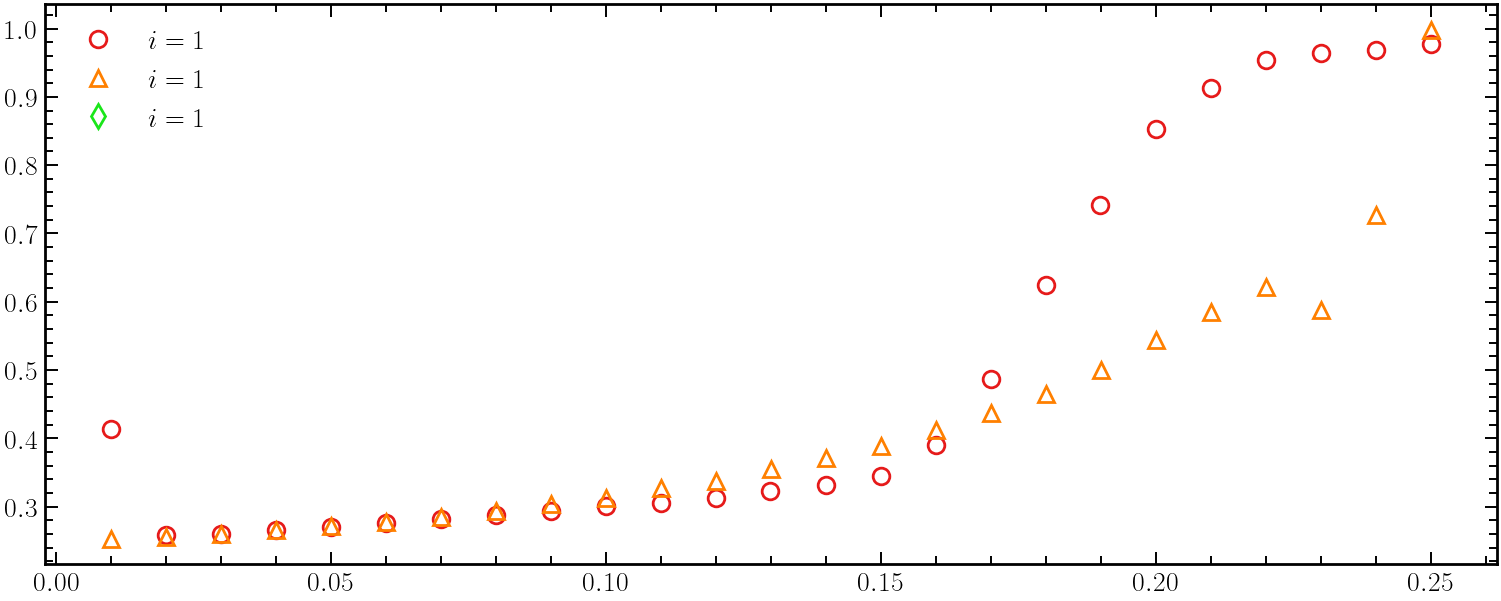

In [128]:
L_lst = [128, 256, 512]
nc = 4
dim = 3
rho = 1/nc
A = L**2
ord = 1
k = 6.0e-06
fig, axes = plt.subplots(
    1, 1, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

for idx, L in enumerate(L_lst):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['dim']==dim) & (df['order']==ord) & (df['k']==k)]
    
    A = L**2
    f_list = [round(i/A,4) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    print(L, pk_list)
    # index = df_sub["p_mean"].idxmin()
    # f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    # p_min = df_sub.loc[index, "p_mean"]

    # print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes.plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
plt.legend()
plt.show()

## $n_c = 4$

minimum value i=1, $\rho$ = 0.2580537907365092 for f = 0.02
minimum value i=2, $\rho$ = 0.2579510957577858 for f = 0.02
minimum value i=3, $\rho$ = 0.2584866042740895 for f = 0.02
minimum value i=4, $\rho$ = 0.2585478737145332 for f = 0.02

k = 1.0e-04
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3112, 3276, 3440, 3604, 3768, 3932, 4096]
Nt faltando   : []
f faltando    : []
minimum value for k=0.0001, $\langle p \rangle$ = 0.2580537907365092 for f = 0.02

k = 5.0e-05
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3112, 3276, 3440, 3604, 3768, 3932, 4096]
Nt faltando   : []
f faltando    : []
minimum value for k=5e-05, $\langle p \rangle$ = 0.2573269063165011 for f = 0.02

k = 1.0e-05
Nt existentes : [163, 327, 491, 655, 819, 983, 1146, 1310, 1474, 1638, 1802, 1966, 2129, 2293, 2457, 2621, 2785, 2949, 3000, 3112, 3276, 3440, 3604, 3768, 3932,

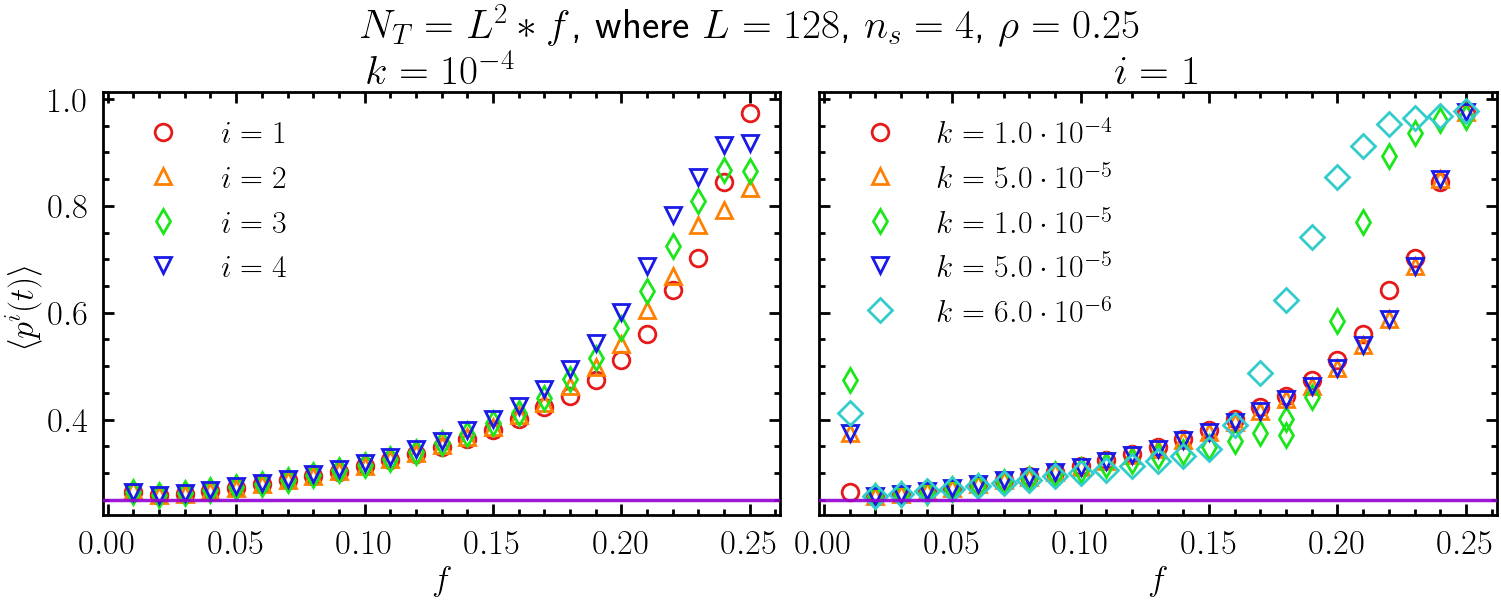

In [ ]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 128
nc = 4
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30

f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['k']==k_lst[0]) & (df['order']==ord)]
    
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == 128) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()

    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    print(f"\nk = {k:.1e}")
    print("Nt existentes :", nt_existentes)
    print("Nt faltando   :", nt_faltando)
    print("f faltando    :", f_faltando)

    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

for ax in axes:
    ax.legend(fontsize=fs_legend)
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $L = {L}$, $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()

minimum value i=1, $\rho$ = 0.252652563698962 for f = 0.01
minimum value i=2, $\rho$ = 0.2527609209345247 for f = 0.01
minimum value i=3, $\rho$ = 0.2530461882310697 for f = 0.01
minimum value i=4, $\rho$ = 0.253306166664736 for f = 0.01

k = 1.0e-04
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553, 7208, 7864, 8519, 15728, 16384]
Nt faltando   : [9175, 9830, 10485, 11141, 11796, 12451, 13107, 13762, 14417, 15073]
f faltando    : [0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23]
minimum value for k=1.0e-04, $\langle p \rangle$ = 0.252652563698962 for f = 0.01

k = 5.0e-05
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553, 7208, 7864, 8519, 9175, 9830, 10485, 11141, 11796, 12451, 13107, 13762, 14417, 15073, 15728, 16384]
Nt faltando   : []
f faltando    : []
minimum value for k=5.0e-05, $\langle p \rangle$ = 0.2521975805126574 for f = 0.01

k = 1.0e-05
Nt existentes : [655, 1310, 1966, 2621, 3276, 3932, 4587, 5242, 5898, 6553,

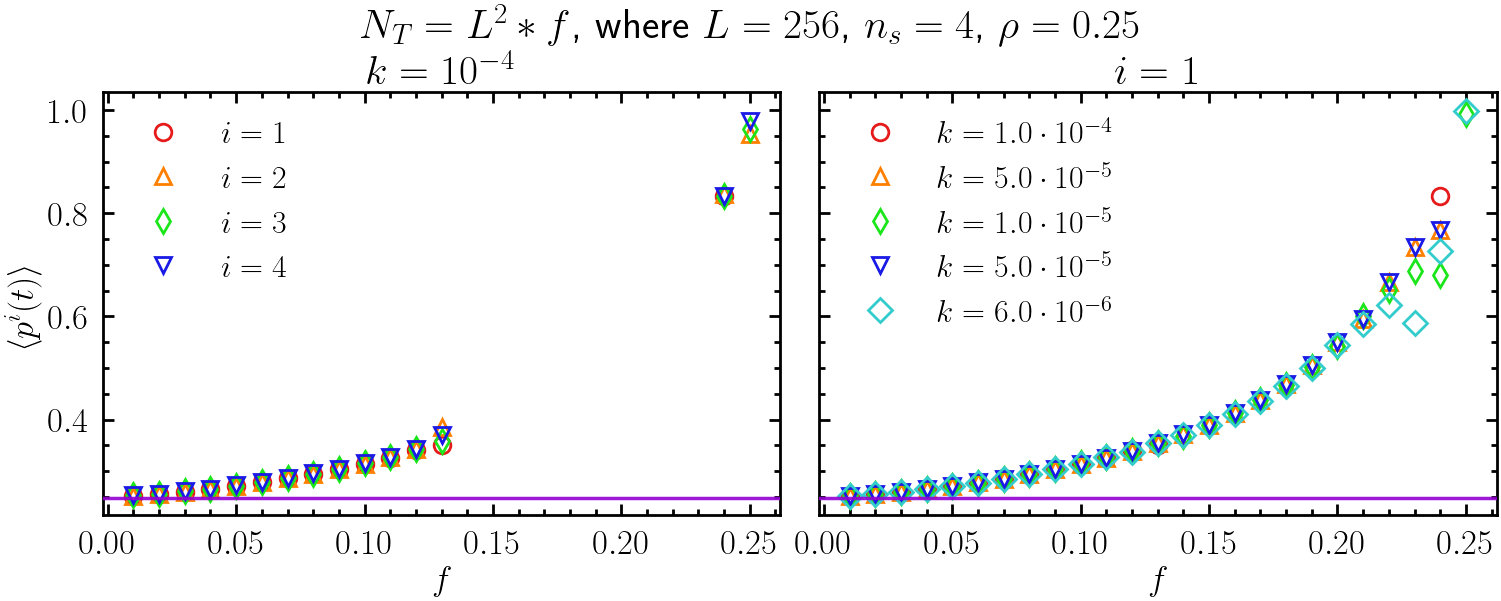

In [5]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 256
nc = 4
rho = 1/nc
A = L**2

orders = [i for i in range(1,nc+1)]

colors = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]
ord = 1
pc = 0.24881182
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
markers = ["o", "^", "d", "v", 'D']
ms = 12
mew = 2.0
lw_pc = 2.5
fs_ticks = 25
fs_legend = 23
fs_label = 25
fs_text = 30
fs_title_figure = 30
for idx, ord in enumerate(orders):
    df_sub = df[(df['L']==L) & (df['rho']==rho) & (df['nc']==nc) & (df['k']==k_lst[0]) & (df['order']==ord)]
    
    f_list = [round(i/A,2) for i in df_sub['Nt'].unique()]
    pk_list = df_sub["p_mean"]
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"]/A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value i={ord}, $\rho$ = {p_min} for f = {f_min}")
    
    axes[0].plot(f_list, pk_list, marker=markers[idx], color=colors[idx], 
                 ls="None", mew=mew, ms=ms, label=f'$i = {ord}$')
print("================")
f00 = [round(i, 2) for i in np.arange(0.01, 0.26, 0.01)]
NT_lst_check = [int(L**2 * f) for f in f00]

for idx, k in enumerate(k_lst):
    df_sub = df[
        (df['L'] == L) &
        (df['rho'] == rho) &
        (df['nc'] == nc) &
        (df['k'] == k) &
        (df['order'] == 1)
    ].sort_values("Nt")

    if df_sub.empty:
        print(f"[WARN] Nenhum dado encontrado para k = {k}")
        continue

    f_list = (df_sub["Nt"] / A).round(2).to_list()
    pk_list = df_sub["p_mean"].to_list()
    
    nt_existentes = sorted(df_sub["Nt"].unique().tolist())
    nt_faltando = sorted(set(NT_lst_check) - set(nt_existentes))
    f_faltando = [round(nt / L**2, 2) for nt in nt_faltando]

    print(f"\nk = {k:.1e}")
    print("Nt existentes :", nt_existentes)
    print("Nt faltando   :", nt_faltando)
    print("f faltando    :", f_faltando)
    
    index = df_sub["p_mean"].idxmin()
    f_min = round(df_sub.loc[index, "Nt"] / A, 2)
    p_min = df_sub.loc[index, "p_mean"]

    print(rf"minimum value for k={k:.1e}, $\langle p \rangle$ = {p_min} for f = {f_min}")

    mantissa, exp = f"{k:.1e}".split("e")
    exp = int(exp)

    axes[1].plot(
        f_list, pk_list,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        ms=ms,
        label=fr'$k = {mantissa} \cdot 10^{{{exp}}}$'
    )

for ax in axes:
    ax.legend(fontsize=fs_legend)
    ax.set_xlabel(r"$f$",fontsize=fs_label)
    ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)
    # major ticks
    ax.tick_params(axis='both', which='major',
                pad=10,      # distância do número
                length=8,
                width=2.0,
                labelsize=fs_ticks)

    # minor ticks (normalmente sem label)
    ax.tick_params(axis='both', which='minor',
                length=4,
                width=2.0)

exp = int(f"{k_lst[0]:.0e}".split("e")[1])


axes[0].set_title(f"$k = 10^{{{exp}}}$", fontsize=fs_text)
axes[1].set_title(f"$i = 1$", fontsize=fs_text)
axes[0].set_ylabel(r"$\langle p^i(t) \rangle$",fontsize=fs_label)
fig.suptitle(fr"$N_T = L^2 * f$, where $L = {L}$, $n_s = {nc}$, $\rho={rho}$", fontsize=fs_title_figure)
plt.show()